# Histogram simulation

In this notebook, we will explain how to simulate a histogram of detection. 

#### Plan of this notebook
1) Brief introduction to the histogram simulation
2) Simulation of a histogram

## 1) Brief introduction to the histogram simulation

The goal of this simulation is to estimate the detection histogram expected from a lidar system given a set of parameters. The detection histogram simulator proceeds as follows:

1) Generate a random number of noise photons based on the noise probability using a binomial distribution.
2) Randomly distribute the noise photons among the histogram bins. Only one noise photon can be detected per bin per trigger.
3) Apply a binomial experiment to determine whether a signal photon is detected in the bin corresponding to the signal arrival time.
4) If a signal photon is detected, add it to the corresponding bin while accounting for detector jitter.
5) If a noise photon is already present in the bin, the signal photon is not added.

This procedure is required because the system operates with non-number-resolving detectors. However, some approximations are made to simplify the simulation. For example, multiple noise photons arriving in the same bin are not considered. Despite these approximations, the simulation provides a reasonable estimate of the detection histogram expected experimentally.

## 2) Simulation of a histogram

In this section, we will simulate a histogram of detection for a given set of parameters. For example, the non-vacuum probability will be fixed. The parameters are the following:

In [3]:
from Sources import SetupParameters, EntangledPhotonSPDC, SinglePhoton, PulsedLaser
from Analysis import HistogramAnalysis
import matplotlib.pyplot as plt

param = SetupParameters(
	fock_space_dim=15,
	output_power=2e7,
	multi_photon_probability=None,
	no_vacuum_probability=None,
	number_nv_pulse=None,
	sp_collection=0.2,
	sp_p1=0.9999,
	sp_p2=1e-4,
	spdc_eps_heralding=0.2*0.9,
	spdc_eps_collection=0.2,
	atmosphere=0.8,
	target_distance=3,
	receiver_diameter=0.5,
	target_albedo=0.5,
	optics_transmitter=0.8,
	optics_receiver=0.5,
	detection_efficiency=0.9,
	background=50000,
	detector_dark=50,
	timing_window=0.5e-9,
	)

sps = SinglePhoton(param, warning_off=True)
param["no_vacuum_probability"] = sps.no_vacuum_probability

print(f"The Non-Vacuum Probability is {param['no_vacuum_probability']*100:.2f}%")

The Non-Vacuum Probability is 16.00%


In order to run a histogram simulation, the following parameters are needed:
- `params`: The SetupParams object containing the parameters of the system.
- `signal_rate`: Amount of signal photons detected per second.
- `noise_rate`: Amount of noise photons detected per second.
- `acquisition_time`: Time in seconds that the LiDAR is acquiring data.
- `range_distance`: Maximum distance that can be resolved by the LiDAR.
- `effective_trigger_rate`: Amount of triggers per second.
- `jitter_std_dev`: Standard deviation of the jitter in the detection time. To reproduce the results by the computation, the jitter_std_dev should be set to 0.

Now, we can extract the parameters needed from all sources:

In [4]:
sps = SinglePhoton(param)
laser = PulsedLaser(param)
spdc = EntangledPhotonSPDC(param)

signal_sps = sps.signal_rate()
noise_sps = sps.noise_rate()

signal_pulsed = laser.signal_rate()
noise_pulsed = laser.noise_rate()

signal_entangled = spdc.signal_rate()
noise_entangled = spdc.noise_rate()

snr_sps = sps.signal_to_noise_rate()
snr_pulsed = laser.signal_to_noise_rate()
snr_entangled = spdc.signal_to_noise_rate()
print(f"SNR SPS: {snr_sps:.2f}")
print(f"SNR Laser: {snr_pulsed:.2f}")
print(f"SNR EPS: {snr_entangled:.2f}")

SNR SPS: 25.31
SNR Laser: 27.58
SNR EPS: 75.73


We now use the `HistogramAnalysis` class to simulate a histogram of detection. This process can take a long time to run. A shorter acquisition time will yield a shorter computation time. Let's define the parameters of the acquisition:

In [5]:
acquisition_time = 1
range_distance = 30
timing_window = param["timing_window"]

The histogram simulation function returns three parameters of interest:
- `counts`: The number of counts detected in each bin.
- `bin_edges`: The edges of the bins in time of flight.
- `bin_edges_distance`: The edges of the bins in distance.

#### Single Photon Source

In [6]:
counts_sps, bin_edges_sps, bin_edges_distance_sps = HistogramAnalysis(param, signal_sps, noise_sps, acquisition_time=acquisition_time, range_distance=range_distance, effective_trigger_rate=SinglePhoton(param).compute_effective_trigger_rate()).histogram_simulation()


100%|██████████| 124987501/124987501 [06:17<00:00, 331505.97it/s]


#### Pulsed Laser

In [7]:
counts_pulsed, bin_edges_pulsed, bin_edges_distance_pulsed = HistogramAnalysis(param, signal_pulsed, noise_pulsed, acquisition_time=acquisition_time, range_distance=range_distance, effective_trigger_rate=PulsedLaser(param).compute_effective_trigger_rate()).histogram_simulation()


100%|██████████| 114699032/114699032 [04:25<00:00, 432734.57it/s]


#### Correlated Photon Pair Source

In [8]:
counts_entangled, bin_edges_entangled, bin_edges_distance_entangled = HistogramAnalysis(param, signal_entangled, noise_entangled, acquisition_time=acquisition_time, range_distance=range_distance, effective_trigger_rate=EntangledPhotonSPDC(param).compute_effective_trigger_rate()).histogram_simulation()

100%|██████████| 18528817/18528817 [00:43<00:00, 423214.07it/s]


#### Plotting the histograms

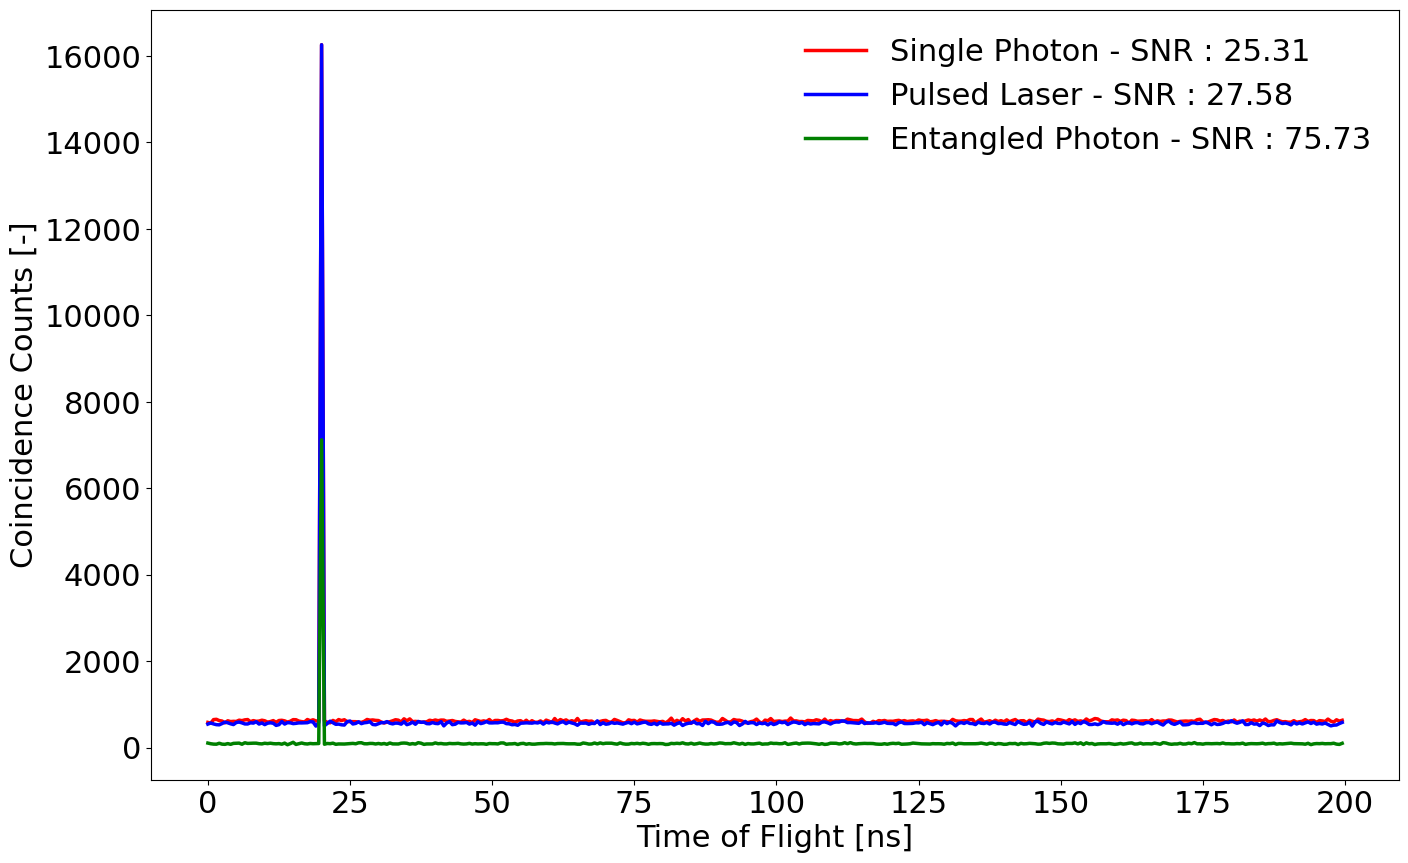

In [9]:
fig = plt.figure(figsize=(16.1, 10))
plt.plot(bin_edges_sps / 1e-9, counts_sps, "-", color="red", label=f"Single Photon - SNR : {snr_sps:.2f}", linewidth=2.5, zorder=1)
plt.plot(bin_edges_pulsed / 1e-9, counts_pulsed, "-", color="blue", label=f"Pulsed Laser - SNR : {snr_pulsed:.2f}", linewidth=2.5, zorder=2)
plt.plot(bin_edges_entangled / 1e-9, counts_entangled, "-", color="green", label=f"Entangled Photon - SNR : {snr_entangled:.2f}", linewidth=2.5, zorder=3)
plt.xlabel('Time of Flight [ns]', fontsize=22)
plt.ylabel('Coincidence Counts [-]', fontsize=22)
plt.tick_params(axis='both', which='major', labelsize=22)
plt.legend(frameon=False, fontsize=22)
plt.show()

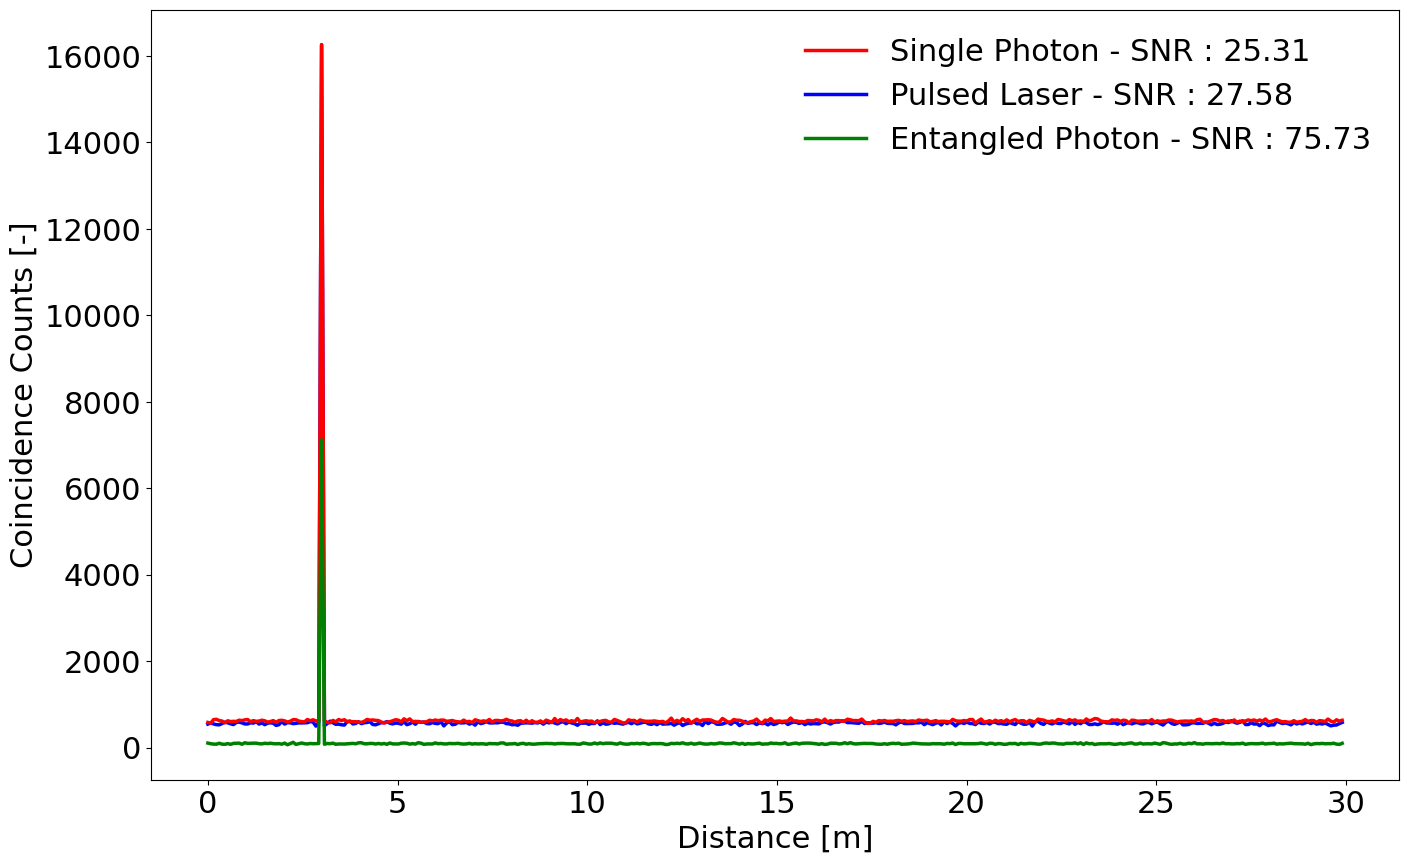

In [10]:
fig = plt.figure(figsize=(16.1, 10))
plt.plot(bin_edges_distance_sps, counts_sps, "-", color="red", label=f"Single Photon - SNR : {snr_sps:.2f}", linewidth=2.5, zorder=2)
plt.plot(bin_edges_distance_pulsed, counts_pulsed, "-", color="blue", label=f"Pulsed Laser - SNR : {snr_pulsed:.2f}", linewidth=2.5, zorder=1)
plt.plot(bin_edges_distance_entangled, counts_entangled, "-", color="green", label=f"Entangled Photon - SNR : {snr_entangled:.2f}", linewidth=2.5, zorder=3)
plt.xlabel('Distance [m]', fontsize=22)
plt.ylabel('Coincidence Counts [-]', fontsize=22)
plt.tick_params(axis='both', which='major', labelsize=22)
plt.legend(frameon=False, fontsize=22)
plt.show()